
# CMB Power Spectra with CLASS — Adiabatic vs. Isocurvature

This notebook computes CMB angular power spectra with **CLASS** (via its Python wrapper `classy`) and lets you explore how different **isocurvature** initial conditions affect the spectra.

**Features**
- Compute TT/TE/EE/BB spectra for a baseline adiabatic ΛCDM cosmology
- Toggle individual isocurvature modes: **CDM (cdi)**, **baryon (bi)**, **neutrino density (nid)**, **neutrino velocity (niv)**
- Control the **fraction** of a chosen isocurvature mode and its **correlation** with adiabatic, along with its spectral tilt and running
- Compare spectra and plot differences

> Notes:  
> - You need a working installation of CLASS with the Python wrapper `classy`.  
> - If `pip install classy` fails on your machine, build CLASS from source and `pip install .` in the `python` folder of the CLASS repository.
> - $D_\ell = \ell (\ell+1) C_\ell / 2\pi$

In [8]:
# If you don't have classy installed, try:
# !pip install classy==3.*  # or the version matching your local CLASS
# If this fails, build CLASS from source and then:
#   cd class_public/python
#   pip install .

import sys, math, numpy as np
import matplotlib.pyplot as plt

try:
    from classy import Class
except Exception as e:
    print("classy is not available in this environment. The rest of the notebook shows how to use it.")
    print("Install instructions above. Error was:", e)

In [9]:
def compute_cls(
    lmax=3000,
    lensing=True,
    A_s=2.1e-9,
    n_s=0.9665,
    tau_reio=0.056,
    omega_b=0.02237,
    omega_cdm=0.1200,
    h=0.6736,
    # isocurvature controls (for one chosen extra mode; extend as needed)
    iso_mode=None,          # 'cdi','bi','nid','niv' or None
    f_iso=0.0,              # 0..1 (typically small)
    c_ad_iso=0.0,           # -1..1
    n_iso=None,             # None -> use n_s
    alpha_iso=0.0
):
    from classy import Class
    import numpy as np

    params = {
        'output': 'tCl,pCl,lCl',                 # <- include lCl so lensing can be computed
        'lensing': 'yes' if lensing else 'no',
        'l_max_scalars': lmax,
        'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio,
        'omega_b': omega_b, 'omega_cdm': omega_cdm, 'h': h,
        'modes': 's',
        'ic': 'ad',
        'P_k_ini type': 'analytic_Pk',
        'k_pivot': 0.05,
        # NOTE: intentionally NOT setting 'l_max_lss' to avoid "not read" errors on some builds.
    }

    if iso_mode is not None and f_iso > 0.0:
        if n_iso is None:
            n_iso = n_s
        params['ic'] = f'ad,{iso_mode}'
        params[f'f_{iso_mode}'] = float(f_iso)
        params[f'c_ad_{iso_mode}'] = float(c_ad_iso)
        params[f'n_{iso_mode}'] = float(n_iso)
        params[f'alpha_{iso_mode}'] = float(alpha_iso)

    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()

    # lensed spectra in K^2 -> convert to μK^2
    cl = cosmo.lensed_cl(lmax)
    ell = cl['ell'][1:]
    TT = cl['tt'][1:] * 1e12
    EE = cl['ee'][1:] * 1e12
    BB = cl['bb'][1:] * 1e12
    TE = cl['te'][1:] * 1e12

    cosmo.struct_cleanup()
    cosmo.empty()
    return {'ell': ell, 'TT': TT, 'EE': EE, 'BB': BB, 'TE': TE}

In [10]:
def plot_cls(cls_dicts, labels, do_dl=True, which=('TT','TE','EE','BB')):
    """Plot multiple spectra on the same axes."""
    ell = cls_dicts[0]['ell']
    plt.figure(figsize=(8,6))
    for cld, lab in zip(cls_dicts, labels):
        for comp in which:
            y = cld[comp]
            if do_dl:
                # convert to D_ell = l(l+1)Cl/2pi
                y = ell*(ell+1)*y/(2*np.pi)
            plt.loglog(ell, y, label=f"{lab} {comp}")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$D_\ell$ [$\mu K^2$]" if do_dl else r"$C_\ell$ [$\mu K^2$]")
    plt.legend(ncol=2, fontsize=9)
    plt.title("CMB Angular Power Spectra")
    plt.tight_layout()
    plt.show()

def plot_difference(base, other, label, do_dl=True, which=('TT','TE','EE','BB')):
    ell = base['ell']
    plt.figure(figsize=(8,6))
    for comp in which:
        yb = base[comp]
        yo = other[comp]
        if do_dl:
            yb = ell*(ell+1)*yb/(2*np.pi)
            yo = ell*(ell+1)*yo/(2*np.pi)
        dy = yo - yb
        plt.semilogx(ell, dy, label=f"{comp}")
    plt.axhline(0, ls='--', lw=0.8)
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$\Delta D_\ell$ [$\mu K^2$]" if do_dl else r"$\Delta C_\ell$ [$\mu K^2$]")
    plt.title(f"Difference vs. baseline: {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

This is our benchmark: **the standard ΛCDM prediction with purely adiabatic perturbations.**

- The **TT** spectrum shows acoustic peaks — sound waves in the photon–baryon fluid before recombination.
- The **EE** polarization peaks are out of phase with TT — because polarization arises from the quadrupole anisotropy of those same oscillations.
- The **TE** spectrum alternates positive and negative correlations as temperature and polarization oscillations swap roles.
- The **BB** here is tiny and comes mainly from lensing — converting some E-modes into B-modes.

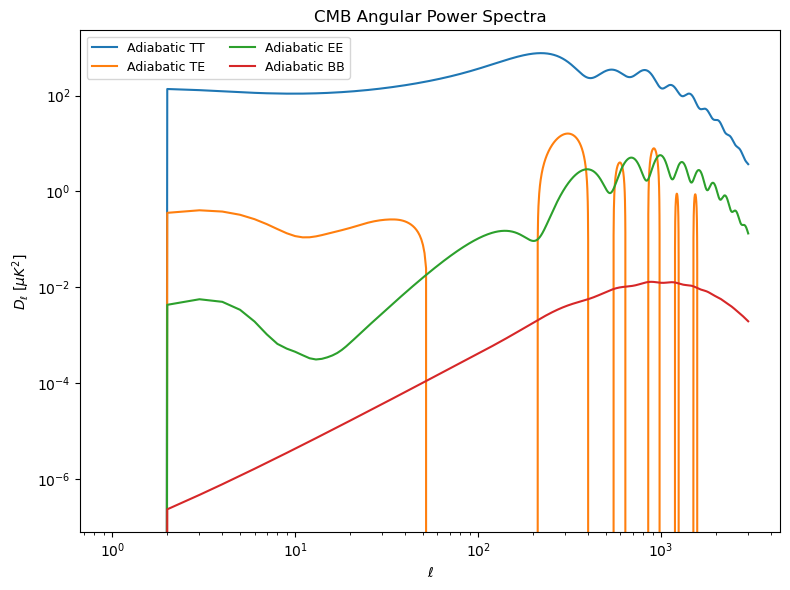

In [19]:
# === Baseline: adiabatic ΛCDM ===
base_cls = compute_cls(lmax=3000)
plot_cls([base_cls], labels=['Adiabatic'], which=('TT','TE','EE','BB'))

Isocurvature tweaks the *relative* initial conditions; correlation lets you add or cancel power at select scales.
- **AD:** all species share curvature perturbation (relative number densities fixed).
- **CDI/BI:** entropy perturbations in CDM/baryons vs photons.
- **NID/NIV:** entropy/velocity modes in neutrinos vs photons.
- **correlation** with adiabatic: constructive/destructive interference in transfer functions.

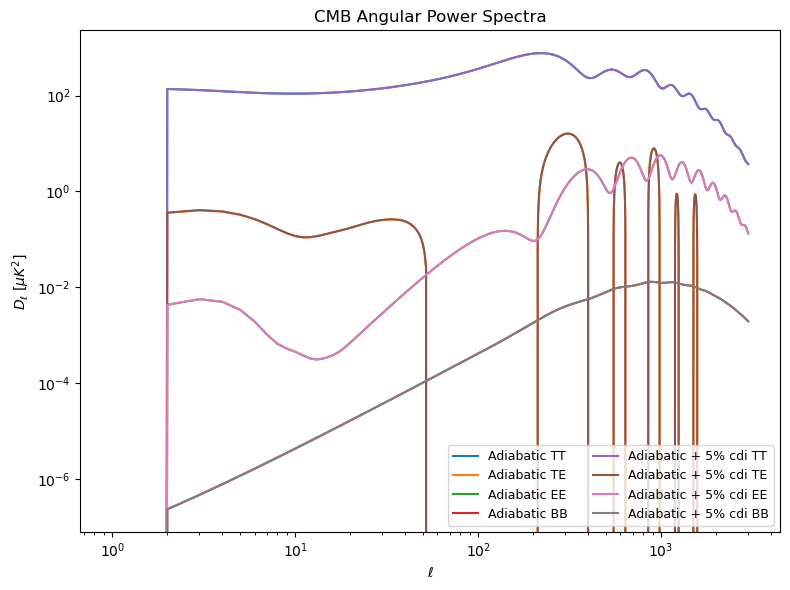

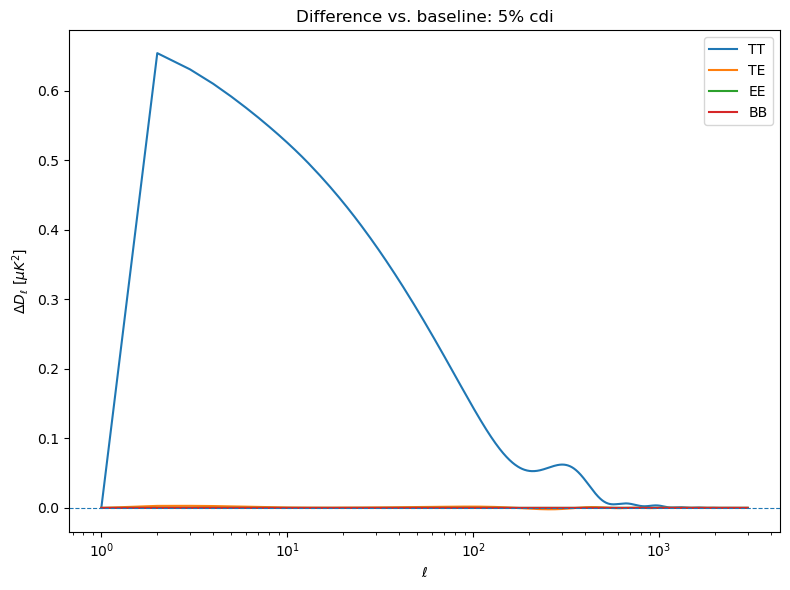

In [14]:
# === Demo: add a small CDM isocurvature (cdi) fraction, uncorrelated ===
cdi_small = compute_cls(iso_mode='cdi', f_iso=0.05, c_ad_iso=0.0)  # 5% fraction
plot_cls([base_cls, cdi_small], labels=['Adiabatic','Adiabatic + 5% cdi'])
plot_difference(base_cls, cdi_small, label='5% cdi')

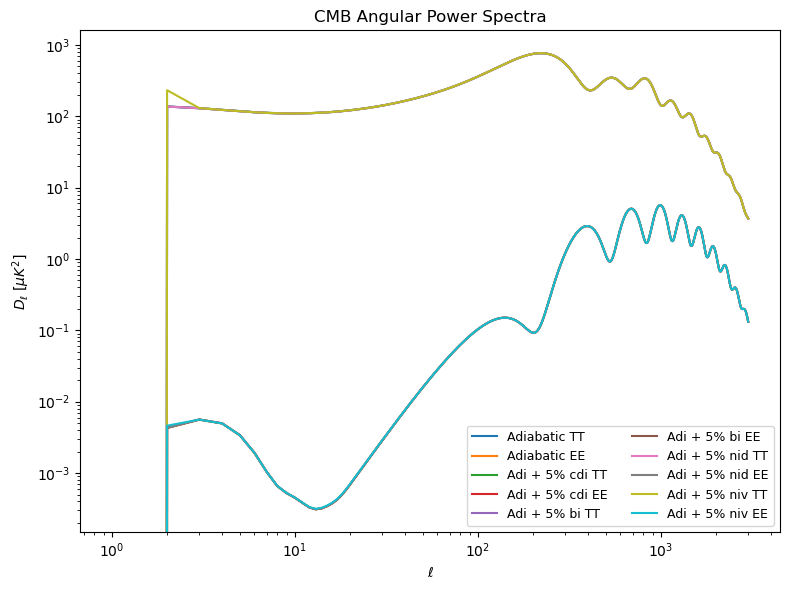

In [20]:
# === Compare modes at the same fraction (uncorrelated) ===
fr = 0.05 # fractional amplitude
c0 = 0.0 # no correlation
demo = []
labs = []
for mode in ['cdi','bi','nid','niv']:
    demo.append(compute_cls(iso_mode=mode, f_iso=fr, c_ad_iso=c0))
    labs.append(f"Adi + {fr:.0%} {mode}")
plot_cls([base_cls] + demo, labels=['Adiabatic'] + labs, which=('TT','EE'))

**Note**: Different isocurvature modes leave qualitatively distinct fingerprints on the CMB — even with the same fractional amplitude — because they perturb different physical components (e.g. CDM, baryons, or relativistic neutrinos) and drive the gravitational potentials in distinct ways. You can see the effect of each interactively below, on the different components of the CMB.

In [16]:
# === Interactive controls (responsive, redraws in-place) ===
try:
    import ipywidgets as W
    from IPython.display import display, Markdown, clear_output

    # Controls
    mode_dd   = W.Dropdown(options=['cdi','bi','nid','niv'], value='cdi', description='iso mode')
    f_iso_sl  = W.FloatLogSlider(base=10, min=-4, max=-0.3, step=0.05, value=0.05, description='f_iso')  # 1e-4 .. ~0.5
    f_iso_lin = W.FloatSlider(min=0.0, max=0.5, step=0.01, value=0.05, description='f_iso (lin)')
    corr_sl   = W.FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='corr c_ad_iso')
    n_iso_sl  = W.FloatSlider(min=0.8, max=1.4, step=0.005, value=0.9665, description='n_iso')
    a_iso_sl  = W.FloatSlider(min=-0.1, max=0.1, step=0.005, value=0.0, description='alpha_iso')
    which_ms  = W.SelectMultiple(options=['TT','TE','EE','BB'], value=('TT','TE','EE','BB'), description='show')
    dl_toggle = W.ToggleButtons(options=[('D_ℓ','D'),('C_ℓ','C')], value='D', description='y-axis')

    # Link log/linear f_iso sliders (use whichever you prefer)
    W.jslink((f_iso_sl, 'value'), (f_iso_lin, 'value'))

    out = W.Output()

    def render(_=None):
        with out:
            clear_output(wait=True)
            try:
                fval = float(f_iso_sl.value)  # same as f_iso_lin via link
                cls_iso = compute_cls(
                    iso_mode=mode_dd.value,
                    f_iso=fval,
                    c_ad_iso=float(corr_sl.value),
                    n_iso=float(n_iso_sl.value),
                    alpha_iso=float(a_iso_sl.value),
                )
                display(Markdown(
                    f"### Mode **{mode_dd.value}** — "
                    f"f_iso={fval:.3g}, corr={corr_sl.value:+.2f}, "
                    f"n_iso={n_iso_sl.value:.3f}, α_iso={a_iso_sl.value:+.3f}"
                ))
                # plot selected spectra
                plot_cls(
                    [base_cls, cls_iso],
                    labels=['Adiabatic', f"Adi + {mode_dd.value}"],
                    do_dl=(dl_toggle.value=='D'),
                    which=tuple(which_ms.value) if which_ms.value else ('TT','TE','EE','BB')
                )
                # differences
                plot_difference(
                    base_cls, cls_iso,
                    label=f"{mode_dd.value}, f={fval:.3g}, c={corr_sl.value:+.2f}",
                    do_dl=(dl_toggle.value=='D'),
                    which=tuple(which_ms.value) if which_ms.value else ('TT','TE','EE','BB')
                )
            except Exception as e:
                print("classy not available or error:", e)

    # Wire up live updates
    for w in (mode_dd, f_iso_sl, f_iso_lin, corr_sl, n_iso_sl, a_iso_sl, which_ms, dl_toggle):
        w.observe(render, names='value')

    controls = W.VBox([
        W.HBox([mode_dd, dl_toggle]),
        W.HBox([which_ms]),
        W.HBox([f_iso_sl, f_iso_lin]),
        W.HBox([corr_sl]),
        W.HBox([n_iso_sl, a_iso_sl]),
    ])
    display(controls, out)
    render()

except Exception as e:
    print("Interactive widgets not available:", e)

Output()

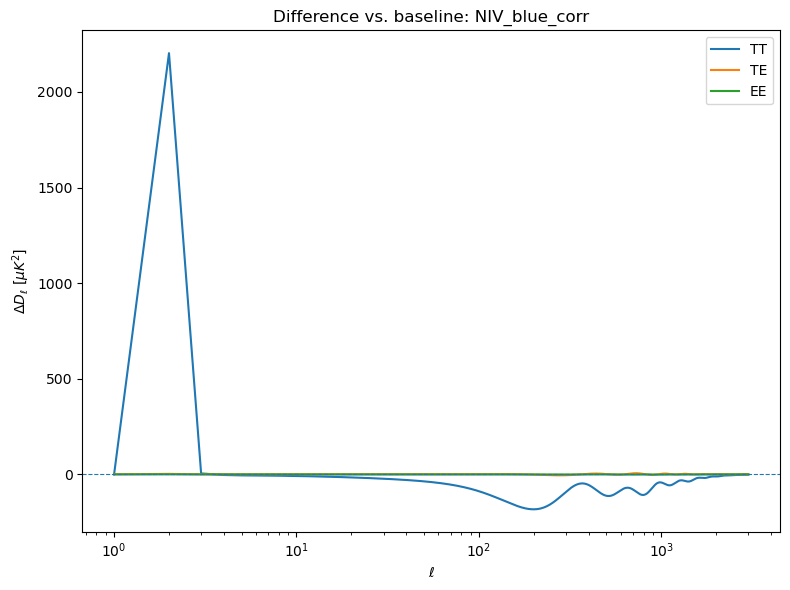

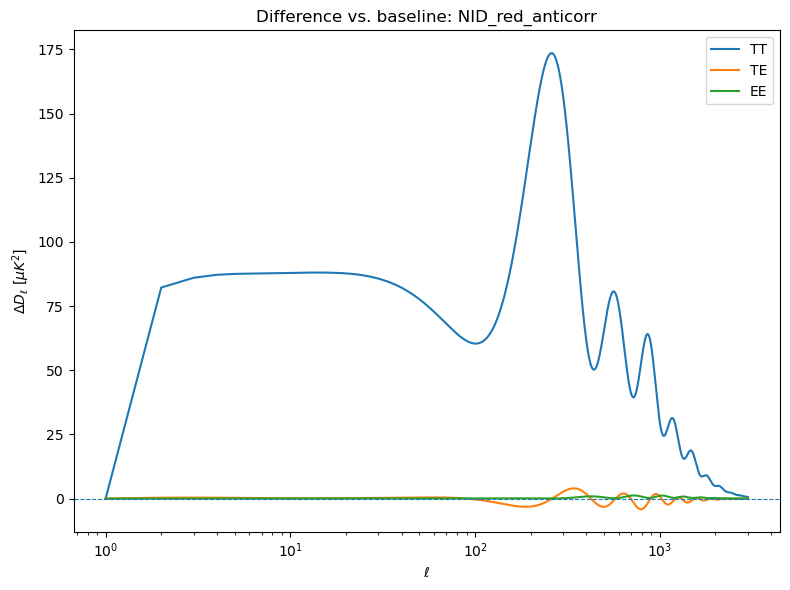

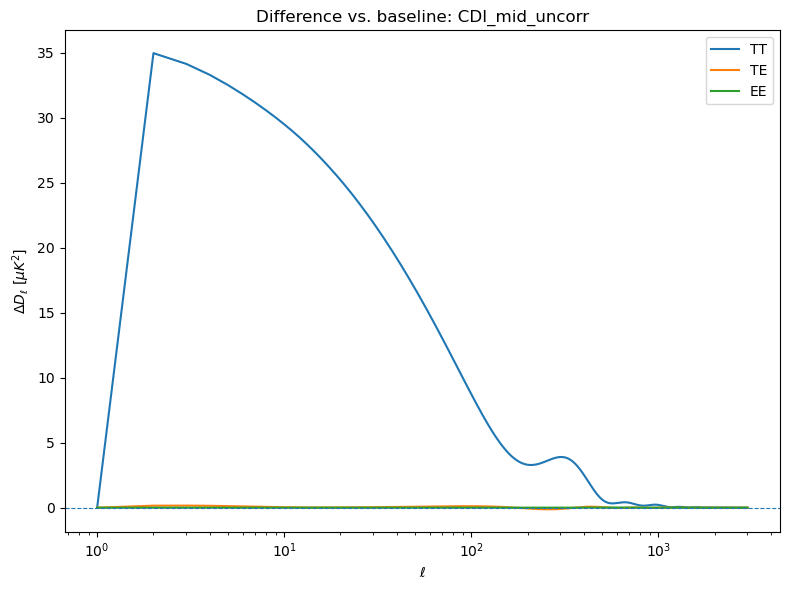

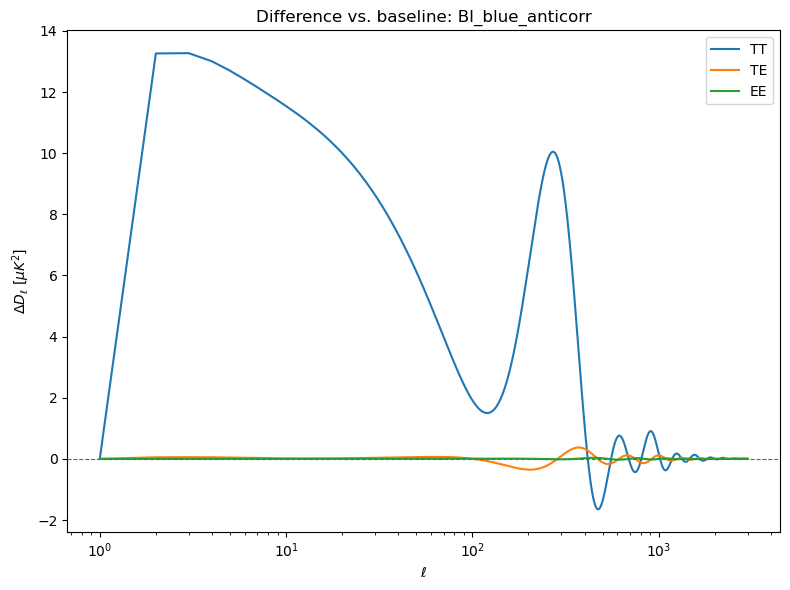

In [17]:
# === Pre-sets ===
# Some (exaggerated) values to highlight different isocurvature signatures
presets = {
  "NIV_blue_corr": dict(iso_mode='niv', f_iso=0.5, c_ad_iso=+0.9, n_iso=1.35, alpha_iso=+0.05),
  "NID_red_anticorr": dict(iso_mode='nid', f_iso=0.5, c_ad_iso=-0.9, n_iso=0.85, alpha_iso=-0.05),
  "CDI_mid_uncorr": dict(iso_mode='cdi', f_iso=0.4, c_ad_iso=0.0, n_iso=1.0, alpha_iso=0.0),
  "BI_blue_anticorr": dict(iso_mode='bi', f_iso=0.4, c_ad_iso=-0.9, n_iso=1.3, alpha_iso=+0.05),
}
for name, kw in presets.items():
    cls_iso = compute_cls(**kw)
    plot_difference(base_cls, cls_iso, label=name, which=('TT','TE','EE'))

#### Homework: Try to answer these questions